# TU3 orbit around Sun

In [1]:
# Load standard modules
import numpy as np
from matplotlib import pyplot as plt

# Load tudatpy modules
from tudatpy.interface import spice
from tudatpy import dynamics
from tudatpy.dynamics import environment_setup, propagation_setup, propagation, simulator
from tudatpy import constants
from tudatpy.astro import element_conversion
from tudatpy.util import result2array
from tudatpy.astro.time_representation import DateTime

In [2]:
import re

params = {}

with open("horizons_results.txt", "r") as file:
    text = file.read()

matches = re.findall(r"([A-Z]+)=\s*([^\s]+)", text)

for key, value in matches:
    try:
        params[key] = float(value)
    except ValueError:
        # skip things like 'n.a.' or dates
        continue

orbit = {
    "semi_major_axis": params.get("A"),
    "eccentricity": params.get("EC"),
    "inclination": params.get("IN"),
    "argument_of_periapsis": params.get("W"),
    "longitude_of_ascending_node": params.get("OM"),
    "mean_anomaly": params.get("MA")
}

print(orbit)

{'semi_major_axis': 0.787092782297079, 'eccentricity': 0.4838099016687703, 'inclination': 5.412722178648383, 'argument_of_periapsis': 84.68464223297437, 'longitude_of_ascending_node': 102.1970210319019, 'mean_anomaly': 354.8400089926715}


In [3]:
semi_major_axis = orbit["semi_major_axis"]
eccentricity = orbit["eccentricity"]
inclination = orbit["inclination"]
argument_of_periapsis = orbit["argument_of_periapsis"]
longitude_of_ascending_node = orbit["longitude_of_ascending_node"]
mean_anomaly = orbit["mean_anomaly"]

# angles: deg → rad
inclination = np.deg2rad(inclination)
argument_of_periapsis = np.deg2rad(argument_of_periapsis)
longitude_of_ascending_node = np.deg2rad(longitude_of_ascending_node)
mean_anomaly = np.deg2rad(mean_anomaly)

# AU → meters
AU = 1.495978707e11
semi_major_axis = semi_major_axis * AU

In [4]:
def mean_to_true_anomaly(M, e, tol=1e-10):
    import numpy as np
    
    # solve for eccentric anomaly E using Newton-Raphson
    E = M
    for _ in range(100):
        E_new = E - (E - e*np.sin(E) - M) / (1 - e*np.cos(E))
        if abs(E_new - E) < tol:
            break
        E = E_new

    # convert to true anomaly
    nu = 2 * np.arctan2(
        np.sqrt(1 + e) * np.sin(E / 2),
        np.sqrt(1 - e) * np.cos(E / 2)
    )
    return nu

true_anomaly = mean_to_true_anomaly(mean_anomaly, eccentricity)

In [5]:
# Load spice kernels
spice.load_standard_kernels()

# Set simulation start and end epochs (total simulation time of 5 years)
simulation_start_epoch = DateTime(2025, 4, 25).to_epoch()
simulation_end_epoch   = simulation_start_epoch + 5 * constants.JULIAN_YEAR

In [6]:
# Define bodies in simulation
bodies_to_create = [
    "Sun"
]
bodies_to_propagate = ["TU3"]

# Create bodies in simulation.
body_settings = environment_setup.get_default_body_settings(bodies_to_create)
body_settings.add_empty_settings("TU3")
body_system = environment_setup.create_system_of_bodies(body_settings)

In [7]:
central_bodies = ["Sun"]
acceleration_settings_TU3 = dict(
    Sun=[propagation_setup.acceleration.point_mass_gravity()]
)

acceleration_settings = {"TU3": acceleration_settings_TU3}

# Create acceleration models
acceleration_models = propagation_setup.create_acceleration_models(
    body_system, acceleration_settings, bodies_to_propagate, central_bodies
)

In [8]:
# Set initial conditions for the satellite that will be
# propagated in this simulation. The initial conditions are given in
# Keplerian elements and later on converted to Cartesian elements
#GVK: what is the gravitational parameter? For example what is its purpose and what are its units?
#influence of Sun's gravity on solar system objects. Uned to simulate the orbit more accuratelly Units: m^3 s^-2
sun_gravitational_parameter = body_system.get("Sun").gravitational_parameter 
initial_state = element_conversion.keplerian_to_cartesian_elementwise(
    gravitational_parameter=sun_gravitational_parameter,
    semi_major_axis=semi_major_axis,
    eccentricity=eccentricity,
    inclination=inclination,
    argument_of_periapsis=argument_of_periapsis,
    longitude_of_ascending_node=longitude_of_ascending_node,
    true_anomaly=true_anomaly,
)

In [9]:
# Create termination settings
termination_settings = propagation_setup.propagator.time_termination(simulation_end_epoch)

# Create numerical integrator settings
#GVK: what are the time_step units?
integrator_settings = propagation_setup.integrator.runge_kutta_fixed_step(
    time_step = 3600.0,#Unit: s
    coefficient_set = propagation_setup.integrator.CoefficientSets.rk_4 )

# Create propagation settings
propagator_settings = propagation_setup.propagator.translational(
    central_bodies,
    acceleration_models,
    bodies_to_propagate,
    initial_state,
    simulation_start_epoch,
    integrator_settings,
    termination_settings
)

In [10]:
# Create simulation object and propagate the dynamics
dynamics_simulator = simulator.create_dynamics_simulator(
    body_system, propagator_settings
)
# Extract the resulting state history and convert it to an ndarray
states = dynamics_simulator.propagation_results.state_history
states_array = result2array(states)

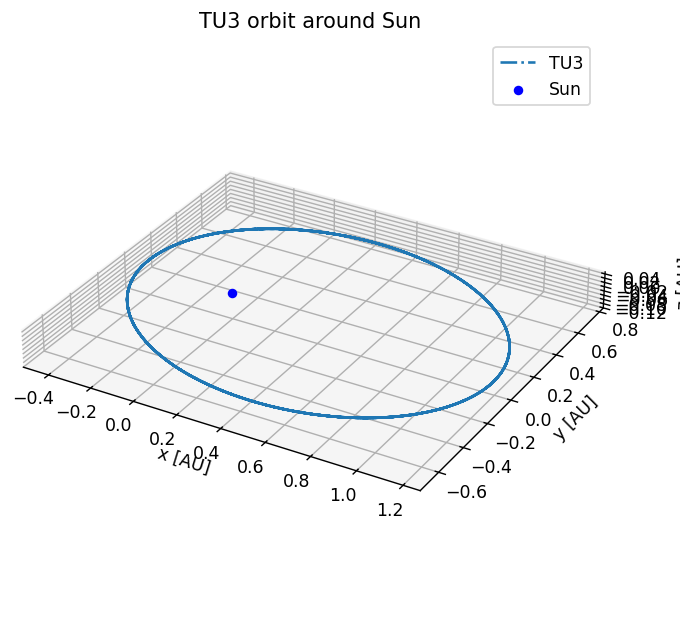

In [11]:
# Define a 3D figure using pyplot
fig = plt.figure(figsize=(6,6), dpi=125)
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f'TU3 orbit around Sun')

# Plot the positional state history
ax.plot(
    states_array[:, 1]/AU,
    states_array[:, 2]/AU,
    states_array[:, 3]/AU,
    label=bodies_to_propagate[0],
    linestyle='-.'
)
ax.scatter(0.0, 0.0, 0.0, label="Sun", marker='o', color='blue')

# Add the legend and labels, then show the plot
ax.legend()
ax.set_xlabel('x [AU]')
ax.set_ylabel('y [AU]')
ax.set_zlabel('z [AU]')
ax.set_aspect('equal')
plt.show()

# TU3 orbit around Sun + planet orbits

In [12]:
# Define bodies in simulation
bodies_to_create = [
    "Moon",
    "Earth",
    "Mars",
    "Venus",
    "Mercury",
    "Sun"
]
bodies_to_propagate = ["TU3"]

# Create bodies in simulation.
body_settings = environment_setup.get_default_body_settings(
    bodies_to_create,
    "Sun",
    "ECLIPJ2000"
)
body_settings.add_empty_settings("TU3")
body_system = environment_setup.create_system_of_bodies(body_settings)

In [13]:
bodies_to_propagate = ["TU3"]
central_bodies = ["Sun"]

#GVK: why did you choose point_mass_gravity? What were the options to choose from?
#models grav attraction of each body at its center allows for a good and accurate simulation of TU3. Other options like radiation pressure might be used later on.                  
acceleration_dict = {
    "TU3": {
        body: [propagation_setup.acceleration.point_mass_gravity()]
        for body in bodies_to_create
    }
}

acceleration_models = propagation_setup.create_acceleration_models(
    body_system=body_system,
    selected_acceleration_per_body=acceleration_dict,
    bodies_to_propagate=bodies_to_propagate,
    central_bodies=central_bodies
)

In [14]:
# Use your previously computed Cartesian state of TU3
# (from keplerian_to_cartesian_elementwise)

system_initial_state = initial_state

for propagation_variant in ["barycentric", "hierarchical"]:
    
    if propagation_variant == "barycentric":
        system_initial_state_barycentric = initial_state
    else:
        system_initial_state_hierarchical = initial_state

In [15]:
#GVK: what is the difference between central_bodies and bodies_to_propagate?
#the state vector is defined relative to central_bodies and the orbit of the bodies_to_propagate is propagated
bodies_to_propagate = ["TU3"]
central_bodies = ["Sun"]

propagator_settings = propagation_setup.propagator.translational(
    central_bodies,
    acceleration_models,
    bodies_to_propagate,
    system_initial_state,
    simulation_start_epoch,
    integrator_settings,
    termination_settings
)

results = simulator.create_dynamics_simulator(
    body_system, propagator_settings
).state_history

In [16]:
times = list(results.keys())
states = list(results.values())

times = np.array(times)
states = np.array(states)

# position only (x, y, z)
tu3_positions = states[:, 0:3]

def get_body_positions(body_name):
    body = body_system.get(body_name)
    return np.array([
        body.state_in_base_frame_from_ephemeris(t)[0:3]
        for t in times
    ])

earth_pos = get_body_positions("Earth")
mars_pos = get_body_positions("Mars")
venus_pos = get_body_positions("Venus")
mercury_pos = get_body_positions("Mercury")
sun_pos = get_body_positions("Sun")

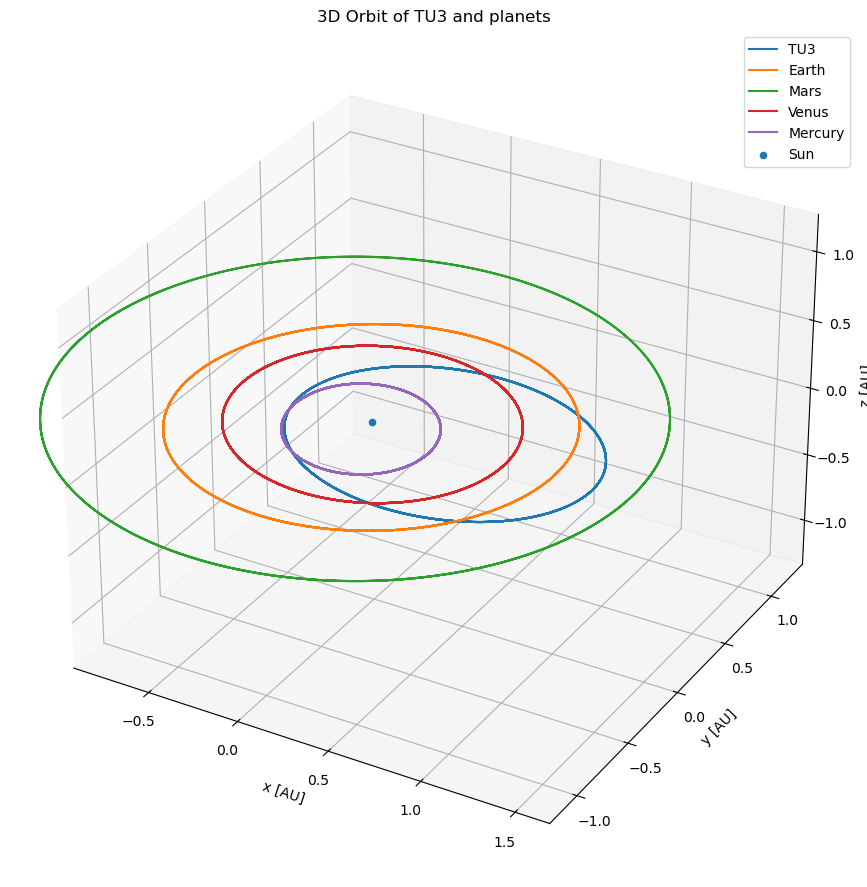

In [17]:
AU = 1.496e11

tu3_positions = tu3_positions / AU
earth_pos = earth_pos / AU
mars_pos = mars_pos / AU
venus_pos = venus_pos / AU
mercury_pos = mercury_pos / AU


fig = plt.figure(figsize=(11, 11))
ax = fig.add_subplot(111, projection='3d')

# TU3
ax.plot(tu3_positions[:,0], tu3_positions[:,1], tu3_positions[:,2], label="TU3")

# Planets
ax.plot(earth_pos[:,0], earth_pos[:,1], earth_pos[:,2], label="Earth")
ax.plot(mars_pos[:,0], mars_pos[:,1], mars_pos[:,2], label="Mars")
ax.plot(venus_pos[:,0], venus_pos[:,1], venus_pos[:,2], label="Venus")
ax.plot(mercury_pos[:,0], mercury_pos[:,1], mercury_pos[:,2], label="Mercury")

id="equalaspect"
max_range = np.array([
    tu3_positions[:,0].max()-tu3_positions[:,0].min(),
    tu3_positions[:,1].max()-tu3_positions[:,1].min(),
    tu3_positions[:,2].max()-tu3_positions[:,2].min()
]).max() / 1.2

mid_x = (tu3_positions[:,0].max()+tu3_positions[:,0].min()) * 0.5
mid_y = (tu3_positions[:,1].max()+tu3_positions[:,1].min()) * 0.5
mid_z = (tu3_positions[:,2].max()+tu3_positions[:,2].min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)
# Sun
ax.scatter(0.0, 0.0, 0.0, label="Sun", marker='o')

# Labels
ax.set_xlabel("x [AU]")
ax.set_ylabel("y [AU]")
ax.set_zlabel("z [AU]")

ax.legend()
ax.set_title("3D Orbit of TU3 and planets")

plt.show()

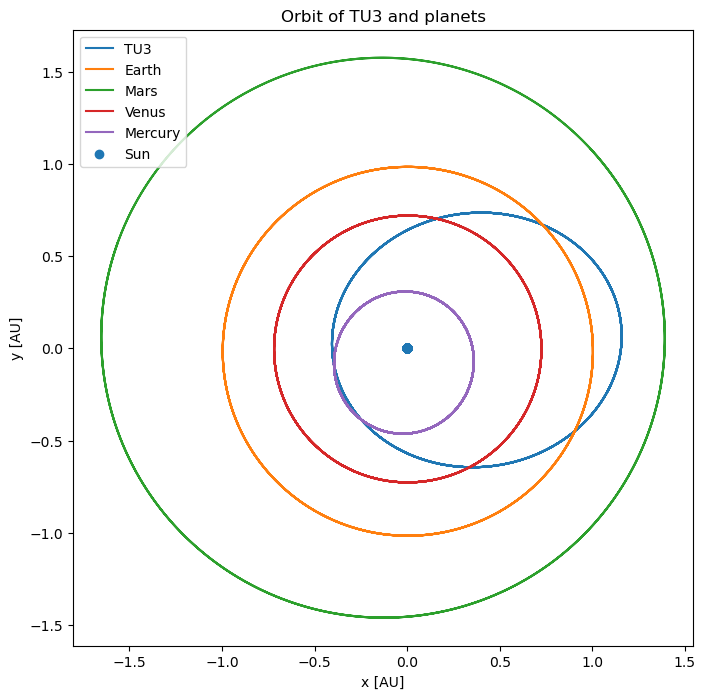

In [18]:
plt.figure(figsize=(8, 8))

# TU3
plt.plot(tu3_positions[:,0], tu3_positions[:,1], label="TU3")

# Planets
plt.plot(earth_pos[:,0], earth_pos[:,1], label="Earth")
plt.plot(mars_pos[:,0], mars_pos[:,1], label="Mars")
plt.plot(venus_pos[:,0], venus_pos[:,1], label="Venus")
plt.plot(mercury_pos[:,0], mercury_pos[:,1], label="Mercury")

# Sun (should be near origin)
plt.scatter(sun_pos[:,0], sun_pos[:,1], label="Sun", marker="o")

plt.xlabel("x [AU]")
plt.ylabel("y [AU]")
plt.legend()
plt.axis("equal")
plt.title("Orbit of TU3 and planets")
plt.show()

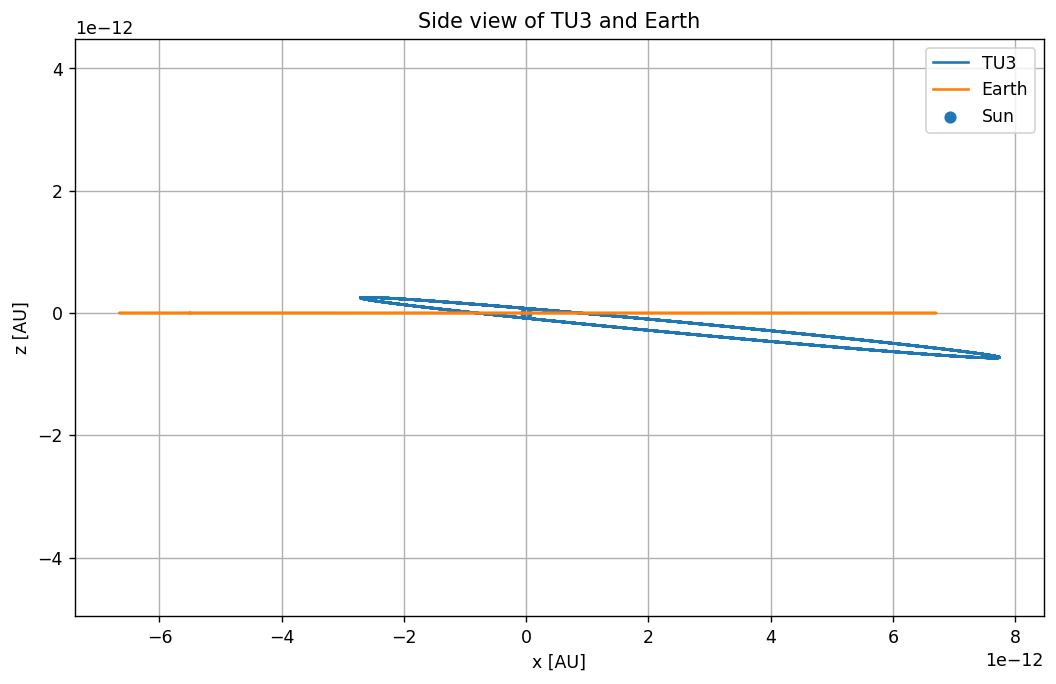

In [19]:
fig = plt.figure(figsize=(10,6), dpi=125)

# TU3
plt.plot(
    tu3_positions[:,0]/AU,
    tu3_positions[:,2]/AU,
    label="TU3"
)

# Planets
plt.plot(
    earth_pos[:,0]/AU,
    earth_pos[:,2]/AU,
    label="Earth"
)

#plt.plot(
#    mars_pos[:,0]/AU,
#    mars_pos[:,2]/AU,
#    label="Mars"
#)

#plt.plot(
#    venus_pos[:,0]/AU,
#    venus_pos[:,2]/AU,
#    label="Venus"
#)

#plt.plot(
#    mercury_pos[:,0]/AU,
#    mercury_pos[:,2]/AU,
#    label="Mercury"
#)

# Sun
plt.scatter(0, 0, label="Sun")

plt.xlabel("x [AU]")
plt.ylabel("z [AU]")

plt.title("Side view of TU3 and Earth")
plt.legend()

plt.axis("equal")
plt.grid(True)

plt.show()

In [20]:
from tudatpy import dynamics
from tudatpy.dynamics import environment_setup, propagation_setup, propagation, simulator

In [21]:
AU = 1.496e11

# Extract x, y, z positions
x = states_array[:, 1]
y = states_array[:, 2]
z = states_array[:, 3]

# Compute distance to Sun at each timestep
r = np.sqrt(x**2 + y**2 + z**2)

# Perihelion distance
perihelion_distance = np.min(r)

print("Perihelion distance [m]:", perihelion_distance)
print("Perihelion distance [km]:", perihelion_distance / 1e3)
print("Perihelion distance [AU]:", perihelion_distance / AU)

Perihelion distance [m]: 60780044431.60903
Perihelion distance [km]: 60780044.431609035
Perihelion distance [AU]: 0.4062837194626272


In [22]:
# Extract x, y, z positions
x = states_array[:, 1]
y = states_array[:, 2]
z = states_array[:, 3]

# Compute distance to Sun at each timestep
r = np.sqrt(x**2 + y**2 + z**2)

# Aphelion distance
aphelion_distance = np.max(r)

print("Aphelion distance [m]:", aphelion_distance)
print("Aphelion distance [km]:", aphelion_distance / 1e3)
print("Aphelion distance [AU]:", aphelion_distance / AU)

Aphelion distance [m]: 174714764222.99503
Aphelion distance [km]: 174714764.222995
Aphelion distance [AU]: 1.1678794399932824


In [23]:
N = 100
q_list = []#perihelion distances
Q_list = []#aphelion distances

sigma_position = 1000.0   # m
sigma_velocity = 0.01     # m/s

#rach iteration creates pertubed orbit-> propagates -> extracts peri/aphelion
for i in range(N):
    # perturb initial state
    perturbation = np.zeros(6)
    perturbation[:3] = np.random.normal(0, sigma_position, 3)
    perturbation[3:] = np.random.normal(0, sigma_velocity, 3)

    perturbed_state = initial_state + perturbation

    # update initial state in propagator
    propagator_settings.initial_states = perturbed_state

    # run propagation
    results = simulator.create_dynamics_simulator(
        body_system, propagator_settings
    ).state_history

    states_array = result2array(results)

    x = states_array[:, 1]
    y = states_array[:, 2]
    z = states_array[:, 3]

    r = np.sqrt(x**2 + y**2 + z**2)

    q_list.append(np.min(r))   # perihelion
    Q_list.append(np.max(r))   # aphelion

print("Perihelion =", np.mean(q_list)/AU, "±", np.std(q_list)/AU, "AU")
print("Aphelion   =", np.mean(Q_list)/AU, "±", np.std(Q_list)/AU, "AU")

Perihelion = 0.4062212868140231 ± 2.1861375347974125e-08 AU
Aphelion   = 1.1681521994101836 ± 1.621062847667096e-06 AU


In [24]:
print("Perihelion =", np.mean(q_list)/1e3, "±", np.std(q_list)/1e3, "km")
print("Aphelion   =", np.mean(Q_list)/1e3, "±", np.std(Q_list)/1e3, "km")

Perihelion = 60770704.507377855 ± 3.2704617520569292 km
Aphelion   = 174755569.03176346 ± 242.5110020109976 km


In [25]:
print("Perihelion Uncetainty =", np.std(q_list)/AU, "AU")
print("Aphelion Uncertainty =", np.std(Q_list)/AU, "AU")
print("Perihelion Uncetainty = 3.163181886230485 km")
print("Aphelion Uncertainty = 223.9264340445041 km")

Perihelion Uncetainty = 2.1861375347974125e-08 AU
Aphelion Uncertainty = 1.621062847667096e-06 AU
Perihelion Uncetainty = 3.163181886230485 km
Aphelion Uncertainty = 223.9264340445041 km


# Calculating Orbital Crossing Distance & Uncertainty

In [26]:
r_tu3 = np.sqrt(
    tu3_positions[:,0]**2 +
    tu3_positions[:,1]**2 +
    tu3_positions[:,2]**2
)

r_earth = 1.0   # AU

difference = r_tu3 - r_earth

crossing_indices = np.where(np.diff(np.sign(difference)))[0]

print(crossing_indices)

for idx in crossing_indices:
    z_distance = abs(tu3_positions[idx,2])

    #print(f"Crossing at index {idx}")
    print(f"Vertical distance from Earth's orbital plane: {z_distance:.5f} AU")

[ 1805  4493  7928 10616 14050 16738 20172 22859 26294 28980 32415 35101
 38536 41222]
Vertical distance from Earth's orbital plane: 0.07211 AU
Vertical distance from Earth's orbital plane: 0.08210 AU
Vertical distance from Earth's orbital plane: 0.07220 AU
Vertical distance from Earth's orbital plane: 0.08207 AU
Vertical distance from Earth's orbital plane: 0.07220 AU
Vertical distance from Earth's orbital plane: 0.08207 AU
Vertical distance from Earth's orbital plane: 0.07220 AU
Vertical distance from Earth's orbital plane: 0.08206 AU
Vertical distance from Earth's orbital plane: 0.07224 AU
Vertical distance from Earth's orbital plane: 0.08207 AU
Vertical distance from Earth's orbital plane: 0.07224 AU
Vertical distance from Earth's orbital plane: 0.08207 AU
Vertical distance from Earth's orbital plane: 0.07224 AU
Vertical distance from Earth's orbital plane: 0.08207 AU


In [27]:
for idx in crossing_indices:

    before = difference[idx]
    after = difference[idx + 1]

    z_distance = abs(tu3_positions[idx,2])

    if before < 0 and after > 0:
        crossing_type = "OUTWARD crossing"

    elif before > 0 and after < 0:
        crossing_type = "INWARD crossing"

    else:
        crossing_type = "Unknown"

    print(crossing_type)
    print(f"Distance from orbital plane: {z_distance:.5f} AU")
    print()

OUTWARD crossing
Distance from orbital plane: 0.07211 AU

INWARD crossing
Distance from orbital plane: 0.08210 AU

OUTWARD crossing
Distance from orbital plane: 0.07220 AU

INWARD crossing
Distance from orbital plane: 0.08207 AU

OUTWARD crossing
Distance from orbital plane: 0.07220 AU

INWARD crossing
Distance from orbital plane: 0.08207 AU

OUTWARD crossing
Distance from orbital plane: 0.07220 AU

INWARD crossing
Distance from orbital plane: 0.08206 AU

OUTWARD crossing
Distance from orbital plane: 0.07224 AU

INWARD crossing
Distance from orbital plane: 0.08207 AU

OUTWARD crossing
Distance from orbital plane: 0.07224 AU

INWARD crossing
Distance from orbital plane: 0.08207 AU

OUTWARD crossing
Distance from orbital plane: 0.07224 AU

INWARD crossing
Distance from orbital plane: 0.08207 AU



In [28]:
N = 100

crossing1_list = []
crossing2_list = []

sigma_position = 1000.0      # m
sigma_velocity = 0.01        # m/s

AU = 1.496e11

for i in range(N):

    # Random perturbation
    perturbation = np.zeros(6)

    perturbation[:3] = np.random.normal(0, sigma_position, 3)
    perturbation[3:] = np.random.normal(0, sigma_velocity, 3)

    perturbed_state = initial_state + perturbation

    propagator_settings.initial_states = perturbed_state

    # Run propagation
    results = simulator.create_dynamics_simulator(
        body_system,
        propagator_settings
    ).state_history

    states_array = result2array(results)

    # Convert to AU
    positions = states_array[:,1:4] / AU

    # Distance from Sun
    r_tu3 = np.sqrt(
        positions[:,0]**2 +
        positions[:,1]**2 +
        positions[:,2]**2
    )

    # Earth orbit crossing
    difference = r_tu3 - 1.0

    crossing_indices = np.where(
        np.diff(np.sign(difference))
    )[0]

    # Take first two crossings only
    d1 = abs(positions[crossing_indices[0],2])
    d2 = abs(positions[crossing_indices[1],2])

    crossing1_list.append(d1)
    crossing2_list.append(d2)

In [34]:
print(
    "Outward Crossing:",
    f"{np.mean(crossing1_list):.5f}",
    "±",
    f"{np.std(crossing1_list):}",
    "AU"
)

print(
    "Inward Crossing:",
    f"{np.mean(crossing2_list):.5f}",
    "±",
    f"{np.std(crossing2_list)}",
    "AU"
)

Outward Crossing: 0.07211 ± 6.565566592096751e-08 AU
Inward Crossing: 0.08210 ± 4.14378368421509e-07 AU


In [30]:
AU_TO_KM = 1.496e8

crossing1_unc_km = np.std(crossing1_list) * AU_TO_KM
crossing2_unc_km = np.std(crossing2_list) * AU_TO_KM

print(
    f"Outward crossing uncertainty: "
    f"{crossing1_unc_km} km"
)

print(
    f"Inward crossing uncertainty: "
    f"{crossing2_unc_km} km"
)


Outward crossing uncertainty: 9.822087621776738 km
Inward crossing uncertainty: 61.991003915857746 km


In [31]:
print(f"Outward Crossing:", np.mean(crossing1_list) * AU_TO_KM,f"km")

print(f"Inward Crossing:", np.mean(crossing2_list) * AU_TO_KM,f"km")

Outward Crossing: 10787280.466360316 km
Inward Crossing: 12282700.026080946 km
